<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>Making Your Model Learn Addition and Subtraction!</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Simple Recurrent Neural Network with Keras)</span>
</div>


---

# Table of Contents 

1. [Task 1: Introduction](#task-1)
2. [Task 2: Generate Data](#task-2)
3. [Task 3: Create the Model](#task-3)
4. [Task 4: Vectorize and De-Vectorize Data](#task-4)
5. [Task 5: Create Dataset](#task-5)
6. [Task 6: Training the Model](#task-6)
   - 6.1 [Test Set Predictions](#task-6-1)
   - 6.2 [Interactive Quiz, Missing Code & Arithmetic Puzzle](#task-6-2)

---


<a id="task-1"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 1: Introduction</span>

Given the string "54+7", the model should return a prediction: "61". The addition example was too easy for the model so I added subtraction in the mix as well. So, please ensure you read the code carefully as it's a little different than the hands on project.


In [1]:
# Modern, learner-friendly imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, LambdaCallback, History
import matplotlib.pyplot as plt
from termcolor import colored

# Display framework version for transparency
print('Using TensorFlow version:', tf.__version__)

Using TensorFlow version: 2.20.0


<a id="task-2"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 2: Generate Data</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___


In [2]:
all_chars = '0123456789+-'

In [3]:
num_features = len(all_chars)

char_to_index = dict((c, i) for i, c in enumerate(all_chars))
index_to_char = dict((i, c) for i, c in enumerate(all_chars))

print('Number of features:', num_features)

Number of features: 12


In [4]:
def generate_data():
    first_num = np.random.randint(low=0,high=100)
    second_num = np.random.randint(low=0,high=100)
    add = np.squeeze(np.random.randint(low=0, high=100)) > 50.
    if add:
        example = str(first_num) + '+' + str(second_num)
        label = str(first_num+second_num)
    else:
        example = str(first_num) + '-' + str(second_num)
        label = str(first_num-second_num)
    return example, label

generate_data()

('15+81', '96')

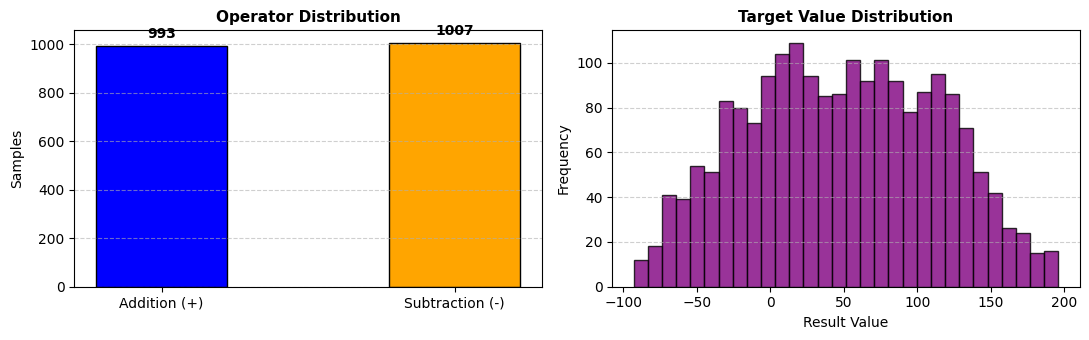

In [5]:
# Dataset distribution: operation balance (+ vs -) and target values
sample_data = [generate_data() for _ in range(2000)]
op_counts = {'Addition (+)': sum(1 for eq, _ in sample_data if '+' in eq),
             'Subtraction (-)': sum(1 for eq, _ in sample_data if '-' in eq)}
target_values = [int(tgt) for _, tgt in sample_data]

plt.figure(figsize=(11, 3.5))

# Operator balance
plt.subplot(1, 2, 1)
bars = plt.bar(list(op_counts.keys()), list(op_counts.values()), color=['blue', 'orange'], edgecolor='black', width=0.45)
for b in bars:
    y = b.get_height()
    plt.text(b.get_x() + b.get_width()/2.0, y + 20, int(y), ha='center', va='bottom', fontweight='bold')
plt.title('Operator Distribution', fontsize=11, fontweight='bold')
plt.ylabel('Samples', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Target distribution
plt.subplot(1, 2, 2)
plt.hist(target_values, bins=30, color='purple', edgecolor='black', alpha=0.8)
plt.title('Target Value Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Result Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


<a id="task-3"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 3: Create the Model</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___

Consider these two reviews:

Review 1: This movie is not terrible at all.

Review 2: This movie is pretty decent.


In [6]:
hidden_units = 128
max_time_steps = 5

model = Sequential([
    SimpleRNN(hidden_units, input_shape=(None, num_features)),
    RepeatVector(max_time_steps),
    SimpleRNN(hidden_units, return_sequences=True),
    TimeDistributed(Dense(num_features, activation='softmax'))
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        18,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 5, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 12)          │         1,548 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,492 (205.05 KB)

 Trainable params: 52,492 (205.05 KB)

 Non-trainable params: 0 (0.00 B)

<a id="task-4"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 4: Vectorize and De-Vectorize Data</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___


In [7]:
def vectorize_example(example, label):
    
    x = np.zeros((max_time_steps, num_features))
    y = np.zeros((max_time_steps, num_features))
    
    diff_x = max_time_steps - len(example)
    diff_y = max_time_steps - len(label)
    
    for i, c in enumerate(example):
        x[diff_x+i, char_to_index[c]] = 1
    for i in range(diff_x):
        x[i, char_to_index['0']] = 1
    for i, c in enumerate(label):
        y[diff_y+i, char_to_index[c]] = 1
    for i in range(diff_y):
        y[i, char_to_index['0']] = 1
        
    return x, y

e, l = generate_data()
print('Text Example and Label:', e, l)
x, y = vectorize_example(e, l)
print('Vectorized Example and Label Shapes:', x.shape, y.shape)

Text Example and Label: 2-38 -36
Vectorized Example and Label Shapes: (5, 12) (5, 12)


In [8]:
def devectorize_example(example):
    result = [index_to_char[np.argmax(vec)] for i, vec in enumerate(example)]
    return ''.join(result)

def strip_padding(example):
    encountered_non_zero = False
    output = ''
    for c in example:
        if not encountered_non_zero and c == '0':
            continue
        if c == '+' or c == '-':
            encountered_non_zero = False
        else:
            encountered_non_zero = True
        output += c
    return output

devectorize_example(x)

'02-38'

In [9]:
print(devectorize_example(y), ':', strip_padding(devectorize_example(y)))

00-36 : -36


<a id="task-5"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 5: Create Dataset</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___


In [10]:
def create_dataset(num_examples=2000):

    x_train = np.zeros((num_examples, max_time_steps, num_features))
    y_train = np.zeros((num_examples, max_time_steps, num_features))

    for i in range(num_examples):
        e, l = generate_data()
        x, y = vectorize_example(e, l)
        x_train[i] = x
        y_train[i] = y
    
    return x_train, y_train

x_train, y_train = create_dataset(20000)
print(x_train.shape, y_train.shape)

(20000, 5, 12) (20000, 5, 12)


In [11]:
devectorize_example(x_train[0])

'82+34'

In [12]:
devectorize_example(y_train[0])

'00116'

<a id="task-6"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 6: Training the Model</span>

___
Note: If you are starting the notebook from this task, you can run cells from all previous tasks in the kernel by going to the top menu and then selecting Kernel > Restart and Run All
___

Please note that the hyper-parameters are a little different and the size of the dataset is different compared to the hands on project example. This model should easily get to 100% accuracy even with 2 operations (+ and -) instead of just 1.


In [13]:
simple_logger = LambdaCallback(
    on_epoch_end=lambda e, l: print('{:.2f}'.format(l['val_accuracy']), end=' _ ')
)
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(x_train, y_train, epochs=100, validation_split=0.2, verbose=False,
         batch_size=1024, callbacks=[simple_logger, early_stopping])

0.56 _ 0.62 _ 0.63 _ 0.64 _ 0.64 _ 0.65 _ 0.65 _ 0.67 _ 0.68 _ 0.69 _ 0.70 _ 0.71 _ 0.72 _ 0.73 _ 0.74 _ 0.75 _ 0.76 _ 0.76 _ 0.77 _ 0.77 _ 0.78 _ 0.78 _ 0.79 _ 0.80 _ 0.81 _ 0.82 _ 0.83 _ 0.84 _ 0.85 _ 0.87 _ 0.88 _ 0.89 _ 0.90 _ 0.91 _ 0.91 _ 0.92 _ 0.93 _ 0.94 _ 0.94 _ 0.95 _ 0.94 _ 0.95 _ 0.96 _ 0.96 _ 0.96 _ 0.96 _ 0.97 _ 0.97 _ 0.97 _ 0.97 _ 0.97 _ 0.98 _ 0.98 _ 0.98 _ 0.98 _ 0.98 _ 0.98 _ 0.98 _ 0.98 _ 0.98 _ 0.98 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.98 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 0.99 _ 1.00 _ 1.00 _ 0.99 _ 0.99 _ 0.99 _ 1.00 _ 1.00 _ 1.00 _ 0.99 _ 1.00 _ 

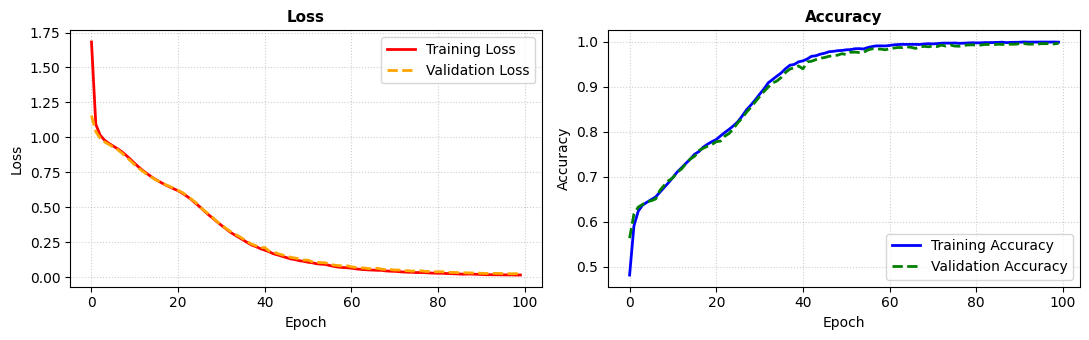

In [14]:
# Training and validation performance over epochs
plt.figure(figsize=(11, 3.5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='red', linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], color='orange', linewidth=2, linestyle='--', label='Validation Loss')
plt.title('Loss', fontsize=11, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='blue', linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='green', linewidth=2, linestyle='--', label='Validation Accuracy')
plt.title('Accuracy', fontsize=11, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


<a id="task-6-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Test Set Predictions</span>

Create a test set and look at some predictions:


In [15]:
x_test, y_test = create_dataset(num_examples=20)
preds = model.predict(x_test)
full_seq_acc = 0

for i, pred in enumerate(preds):
    pred_str = strip_padding(devectorize_example(pred))
    y_test_str = strip_padding(devectorize_example(y_test[i]))
    x_test_str = strip_padding(devectorize_example(x_test[i]))
    col = 'green' if pred_str == y_test_str else 'red'
    full_seq_acc += 1/len(preds) * int(pred_str == y_test_str)
    outstring = 'Input: {}, Out: {}, Pred: {}'.format(x_test_str, y_test_str, pred_str)
    print(colored(outstring, col))
print('\nFull sequence accuracy: {:.3f} %'.format(100 * full_seq_acc))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Input: 61+55, Out: 116, Pred: 116
Input: 30-18, Out: 12, Pred: 12
Input: 33-38, Out: -5, Pred: -5
Input: 76+38, Out: 114, Pred: 114
Input: 83+36, Out: 119, Pred: 119
Input: 75+85, Out: 160, Pred: 160
Input: 4-10, Out: -6, Pred: -6
Input: 7+26, Out: 33, Pred: 33
Input: 51+85, Out: 136, Pred: 136
Input: 42-84, Out: -42, Pred: -42
Input: 53-80, Out: -27, Pred: -27
Input: 29+66, Out: 95, Pred: 95
Input: 37+83, Out: 120, Pred: 120
Input: 65-56, Out: 9, Pred: 19
Input: 22+41, Out: 63, Pred: 63
Input: 17+64, Out: 81, Pred: 81
Input: 32-, Out: 32, Pred: 32
Input: 14+80, Out: 94, Pred: 94
Input: 61-87, Out: -26, Pred: -26
Input: 71+62, Out: 133, Pred: 133

Full sequence accuracy: 95.000 %


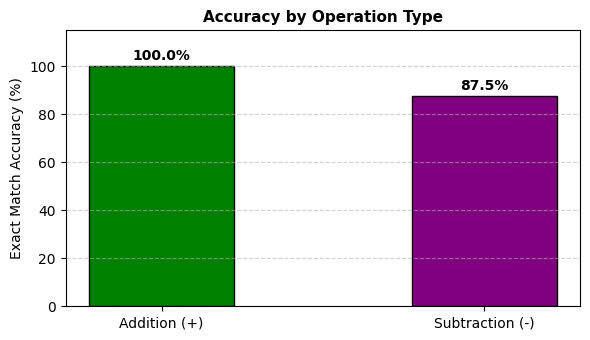

In [16]:
# Accuracy breakdown: Addition vs Subtraction
add_total, add_correct = 0, 0
sub_total, sub_correct = 0, 0

for i, pred in enumerate(preds):
    p_str = strip_padding(devectorize_example(pred))
    y_str = strip_padding(devectorize_example(y_test[i]))
    x_str = strip_padding(devectorize_example(x_test[i]))
    is_correct = (p_str == y_str)
    if '+' in x_str:
        add_total += 1
        if is_correct: add_correct += 1
    else:
        sub_total += 1
        if is_correct: sub_correct += 1

acc_add = (add_correct / add_total * 100) if add_total > 0 else 100.0
acc_sub = (sub_correct / sub_total * 100) if sub_total > 0 else 100.0

plt.figure(figsize=(6, 3.5))
bars = plt.bar(['Addition (+)', 'Subtraction (-)'], [acc_add, acc_sub], color=['green', 'purple'], width=0.45, edgecolor='black')
for b in bars:
    y = b.get_height()
    plt.text(b.get_x() + b.get_width()/2.0, y + 1.5, f"{y:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Accuracy by Operation Type', fontsize=11, fontweight='bold')
plt.ylabel('Exact Match Accuracy (%)', fontsize=10)
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<a id="task-6-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Interactive Quiz, Missing Code & Arithmetic Puzzle</span>

Deepen your grasp of multi-operator sequence modeling with this interactive quiz, missing code challenge, and custom addition/subtraction puzzle solver.


### Concept Check: Multi-Operator Sequence Learning

**1. Why is subtraction harder for the RNN to learn than addition?**
- **A)** Subtraction can produce negative numbers, requiring the network to output a minus sign (`'-'`)
- **B)** Subtraction requires borrow logic across digits
- **C)** Subtraction results span a wider output range (both positive and negative values)
- **D)** All of the above

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: D**  
> Subtraction introduces multiple challenges simultaneously: negative results require an extra symbol token (`'-'`), borrowing requires looking ahead across adjacent digits, and target values range from negative to positive numbers.
</details>

---

**2. How does `strip_padding()` preserve valid zeros inside numbers like `"105"`?**
- **A)** It tracks a boolean flag (`encountered_non_zero`) so leading zeros are stripped, but once a non-zero digit is seen, internal zeros are kept
- **B)** It replaces all zeros with spaces
- **C)** It casts strings to integers and back
- **D)** It deletes characters at even indices

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: A**  
> By toggling `encountered_non_zero = True` when the first real digit appears, leading alignment zeros (e.g. `'00105'`) are removed while internal zeros (`'105'`) remain intact.
</details>


In [17]:
# Exercise: Generate balanced addition & subtraction examples
def generate_custom_operation():
    num1 = np.random.randint(0, 100)
    num2 = np.random.randint(0, 100)
    
    # 50% probability of addition vs subtraction
    if np.random.rand() < 0.5:
        return f"{num1}+{num2}", str(num1 + num2)
    else:
        return f"{num1}-{num2}", str(num1 - num2)

# Test generation
for _ in range(5):
    problem, answer = generate_custom_operation()
    print(f"{problem:<8} = {answer}")


53+56    = 109
24-10    = 14
17+90    = 107
76-26    = 50
68-34    = 34


In [18]:
# Helper to test custom addition or subtraction on our trained model
def predict_arithmetic(equation_str):
    diff = max_time_steps - len(equation_str)
    if diff < 0:
        return f"Too long (max {max_time_steps} chars)"
        
    x_input = np.zeros((1, max_time_steps, num_features))
    for i in range(diff):
        x_input[0, i, char_to_index['0']] = 1
    for i, c in enumerate(equation_str):
        if c in char_to_index:
            x_input[0, diff + i, char_to_index[c]] = 1
            
    pred = model.predict(x_input, verbose=0)[0]
    return strip_padding(devectorize_example(pred))

# Test a set of custom addition and subtraction problems
puzzles = ['45+15', '50-20', '80-15', '33+44', '12-9']
for p in puzzles:
    res = predict_arithmetic(p)
    expected = eval(p)
    status = 'PASS' if res == str(expected) else 'MISMATCH'
    print(f"{p:<8} -> Model: {res:<5} | Expected: {expected:<5} [{status}]")


45+15    -> Model: 60    | Expected: 60    [PASS]
50-20    -> Model: 30    | Expected: 30    [PASS]
80-15    -> Model: 65    | Expected: 65    [PASS]
33+44    -> Model: 77    | Expected: 77    [PASS]
12-9     -> Model: 3     | Expected: 3     [PASS]
